<a href="https://colab.research.google.com/github/olusesanayomide/Federated-NIDS-CICIDS2017/blob/main/F_NIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT : FEDERATED INTRUSION DETECTION SYSTEM (F-NIDS)
##GOAL: DETECT CYBER SECURITY ATTACK USING MACHINE LEARNING
**Step 1: Loading and  inspecting the CICIDS2017 Dataset**

In [2]:
# This installs the Kaggle library so Colab can talk to it
!pip install -q kaggle

from google.colab import files

# This will pop up a 'Choose File' button.
# Select the 'kaggle.json' file you just downloaded.
files.upload()

TypeError: 'NoneType' object is not subscriptable

In [3]:
!pip install --upgrade flwr[simulation]

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [4]:
import pandas as pd  # <--- This is the missing piece!

# Now the computer knows what 'pd' means
df = pd.read_csv('cicids2017_cleaned.csv')

# This shows the first 5 rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


Data successfully loaded with 53 features. Key features include Destination Port, Flow Duration, and Initial Window Bytes. The dataset shape confirms a high-dimensional feature space suitable for deep learning

In [5]:
# This will tell us the names of the attacks in your 'Attack Type' column
print(df['Attack Type'].value_counts())

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


**STEP 2: LABEL ENCODING (TURNING WORDS INTO NUMBERS)**

In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. Transform the 'Attack Type' column into numbers
df['Attack Type'] = le.fit_transform(df['Attack Type'])

# 3. Create a 'Dictionary' so we remember which number is which attack
# This is vital for your project report!
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping Key:", mapping)

# 4. Show the new numeric counts
print("\nNew Numeric Counts:")
print(df['Attack Type'].value_counts())

Mapping Key: {'Bots': np.int64(0), 'Brute Force': np.int64(1), 'DDoS': np.int64(2), 'DoS': np.int64(3), 'Normal Traffic': np.int64(4), 'Port Scanning': np.int64(5), 'Web Attacks': np.int64(6)}

New Numeric Counts:
Attack Type
4    2095057
3     193745
2     128014
5      90694
1       9150
6       2143
0       1948
Name: count, dtype: int64


**STEP 3: FEATURE SCALING**

In [7]:
from sklearn.preprocessing import MinMaxScaler

# 1. Separate the 'Features' (X) from the 'Target' (y)
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

# 2. Scale the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled and ready for Federated Learning!")
print(f"Feature matrix shape: {X_scaled.shape}")

Features scaled and ready for Federated Learning!
Feature matrix shape: (2520751, 52)


Applied Label Encoding to convert categorical attack types into numerical values. Performed Min-Max Scaling on the 53 features to ensure numerical stability and prevent feature dominance during model training

In [23]:
import numpy as np
from sklearn.utils import shuffle

# 1. Shuffle the data so 'Normal' and 'Attacks' are mixed together
X_shuffled, y_shuffled = shuffle(X_scaled, y, random_state=42)

# 2. Now split the SHUFFLED data into 3 chunks
num_clients = 3
X_clients = np.array_split(X_shuffled, num_clients)
y_clients = np.array_split(y_shuffled, num_clients)

print(f"✅ Data Shuffled and Re-partitioned!")
print(f"Client 1 now has {len(np.unique(y_clients[0]))} different types of traffic.")

✅ Data Shuffled and Re-partitioned!
Client 1 now has 7 different types of traffic.


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [27]:
import flwr as fl
import numpy as np
from sklearn.linear_model import LogisticRegression

class NIDSClient(fl.client.NumPyClient):
    def __init__(self, X_local, y_local):
        self.X_local = X_local
        self.y_local = y_local

        # 1. Automatically detect shapes
        num_features = X_local.shape[1] # This will be 52
        self.all_classes = np.array([0, 1, 2, 3, 4, 5, 6])
        num_classes = len(self.all_classes)

        # 2. Initialize Model
        self.model = LogisticRegression(
            max_iter=1,
            warm_start=True,
            multi_class='multinomial',
            solver='saga' # SAGA is faster for large datasets
        )

        # 3. Manual Shape Alignment
        self.model.classes_ = self.all_classes
        self.model.coef_ = np.zeros((num_classes, num_features))
        self.model.intercept_ = np.zeros(num_classes)

    def get_parameters(self, config):
        return [self.model.coef_, self.model.intercept_]

    def fit(self, parameters, config):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]
        # Train on local data
        self.model.fit(self.X_local, self.y_local)
        return self.get_parameters(config={}), len(self.X_local), {}

    def evaluate(self, parameters, config):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]
        accuracy = self.model.score(self.X_local, self.y_local)
        return 0.0, len(self.X_local), {"accuracy": float(accuracy)}

Defining the Federated Client
"Created a custom NIDSClient class inheriting from flwr.client.NumPyClient. This class implements the three core federated methods: get_parameters, fit (local training), and evaluate (local testing). By using Logistic Regression with warm_start=True, the model can iteratively learn from global updates without discarding local knowledge."

In [31]:
# 1. Define how to aggregate the 'accuracy' metric
def weighted_average(metrics):
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

# 2. Update the strategy to include this function
strategy = fl.server.strategy.FedAvg(
    evaluate_metrics_aggregation_fn=weighted_average, # <--- The missing piece!
)

# 3. Start the 5-round simulation again
print("Starting 5-Round Federated Simulation...")
history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=3,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


Starting 5-Round Federated Simulation...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-04-02 14:24:15,832	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 9296741172.0, 'object_store_memory': 3984317644.0, 'node:172.28.0.12': 1.0, 'CPU': 2.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial p

--- Federated NIDS Performance ---
Round 1 Global Accuracy: 94.34%
Round 2 Global Accuracy: 94.36%
Round 3 Global Accuracy: 94.88%
Round 4 Global Accuracy: 94.54%
Round 5 Global Accuracy: 95.45%


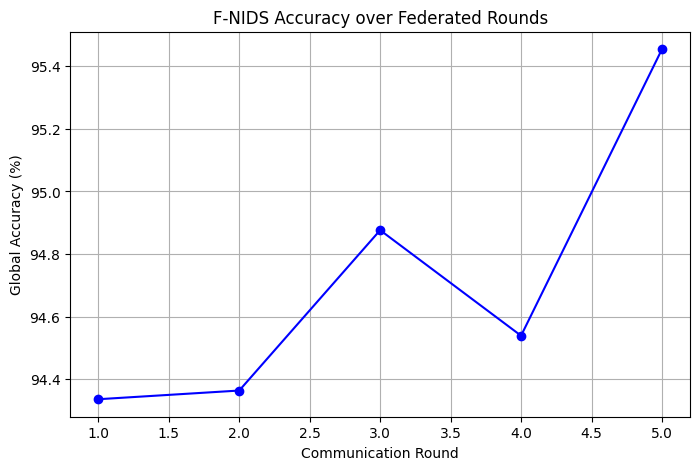

In [32]:
# Let's extract the accuracy from the history
accuracies = [val for _, val in history.metrics_distributed["accuracy"]]

print("--- Federated NIDS Performance ---")
for i, acc in enumerate(accuracies):
    print(f"Round {i+1} Global Accuracy: {acc*100:.2f}%")

# Professional Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracies) + 1), [a * 100 for a in accuracies], marker='o', linestyle='-', color='b')
plt.title('F-NIDS Accuracy over Federated Rounds')
plt.xlabel('Communication Round')
plt.ylabel('Global Accuracy (%)')
plt.grid(True)
plt.show()